In [2]:
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sympy.printing.pytorch import torch
from torch._C import dtype

torch.manual_seed(42)

In [3]:
CSV_FILENAME = "clean_autonomous_taxi_rides.csv"

In [4]:
df = pd.read_csv(CSV_FILENAME)
df

,trip_distance_miles,pickup_hour,passenger_count,ride_duration_min
0,2.5,8,1,9.0
1,4.0,9,1,12.0
2,6.0,17,2,18.0
3,8.5,18,2,24.0
4,10.0,7,1,27.0
5,12.0,12,3,31.0
6,15.0,16,2,39.0
7,18.0,20,1,46.0


In [5]:
feature_col = "trip_distance_miles"
target_col = "ride_duration_min"

In [6]:
X = df[[feature_col]].values.astype("float32")
y = df[[target_col]].values.astype("float32")

In [7]:
X.shape, y.shape

((8, 1), (8, 1))

In [8]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:",X_train_np.shape)
print("X_test shape:",X_test_np.shape)
print("y_train shape:",y_train_np.shape)
print("y_test shape:",y_test_np.shape)

X_train shape: (6, 1)
X_test shape: (2, 1)
y_train shape: (6, 1)
y_test shape: (2, 1)


In [9]:
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print("X_train tensor shape:",X_train.shape)
print("X_test tensor shape:",X_test.shape)
print("y_train tensor shape:",y_train.shape)
print("y_test tensor shape:",y_test.shape)

X_train tensor shape: torch.Size([6, 1])
X_test tensor shape: torch.Size([2, 1])
y_train tensor shape: torch.Size([6, 1])
y_test tensor shape: torch.Size([2, 1])


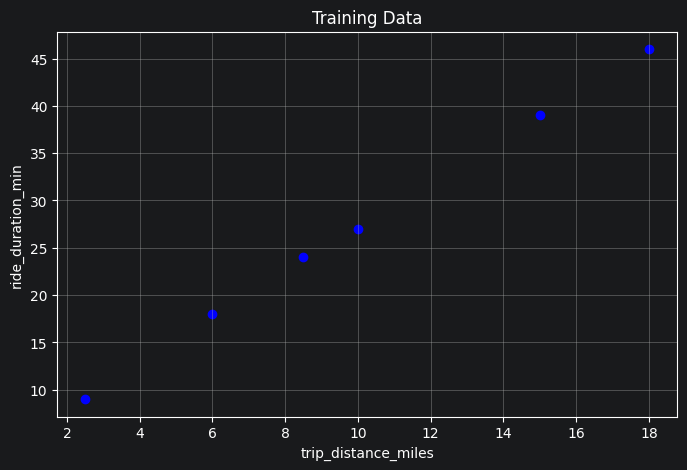

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(X_train_np, y_train_np, color="blue")
plt.xlabel(feature_col)
plt.ylabel(target_col)
plt.title("Training Data")
plt.grid(True)
plt.show()